# Introduction

This project uses an end to end multimodal deep learning pipeline of Visual Entailment: the model allows predicting whether a hypothesis sentence is or is not entailed in an image (premise) or not. The system is a combination of an image backbone which is trained beforehand (efficientnet_b3_ra2_imagenet) and a trainable text encoder, also featuring thoughtful preprocessing and class-imbalance management, hyperparameter tuning with built-in resume support, and gives future data inference-ready predictions.

Target (predicting the Label):
* entailment.
* contradiction.

The pipeline starts with the reading of the annotated image-text pair and the division of it into training, validation, and test sets with maintaining the proportions of the classes. Images are always preprocessed by converting them to RGB, downsampling them to a fixed resolution, and adjusting pixel values to the mean value, and are also enhanced with light transformations that include flips, small turns, displacements and zoom to enhance generalization. A learned vocabulary is used to encode hypotheses into integer sequences which are padded to a fixed length in order to produce uniform inputs to the text branch. In order to overcome the problem of class imbalance, balanced weights of classes are calculated using the training labels and can be used during optimization. It is then followed by the model combining high-level visual representations of a trained image backbone with a sequence representation of an LSTM-based text encoder and dense layers of multimodal reasoning and final classification. Hyperparameter tuning iterated the model width, model regularization, sequence units and learning rates are sampled over, and the training is stabilized and a learning-rate scheduler used to choose a model with good validation-set performance. Validation, test, and deployment follow the same logic in preprocessing and batching and after identifying the best model it is only evaluated on the held-out test set once.

Model Approach -
* Baseline-
    * Vision EfficientNetB3 backbone (kerashub preset) frozen.
    * Text: LSTM (64) embedding, which is trainable.
    * Fusion: image / text fusion- Dense(64) +Dropout.
    * Entailment, contradiction, output softmax.
* Tuned configuration (hyperparameter search)-
    * vision e.g. [256,128,64], [512,256,128], [768,384,192], [1024,512,256] BatchNorm, Dropout, L2.
    * Head text: The number of embedded units (e.g. 64/128/192/256) and BatchNorm + Dropout was variable (e.g. Dense + BatchNorm + Dropout).
    * Fusion E.g., 128-512, BatchNorm, and Dropout, dense.
    * Optimizer: Adam and learning rate (e.g. 5e-5 -1e-3).

Features and Capabilities:
* A pre-trained visual backbone (efficientnet_b3_ra2_imagenet) encoder text LSTM was trained.
* Single pass processing: text normalization; image normalization; tokenization, text clipping and text padding.
* Strong Image augmentation (flip/brightness/rotation/translation/zoom)
* Using class weight to reduce imbalance between classes computeclass weight and optional training time class weight.
* Stratified training/validation/test split and a jamming Keras Sequence generator.
* Early stoppping, LR schedule, per-config checkpoints, and Hyperparameter.
* Assessment makes use of confusion, classification reports, history plots.

The evaluation framework gives accuracy, macro-precision, macro-recall, and macro-F1 as well as the confusion matrices and per-class reports. F1 is most crucial as it puts equal weightage to all classes and is more suitable when there is imbalance in the class than the accuracy. Validation performance is only used in model selection, and only a held-out test set is assessed once the optimal configuration is selected. The diagnostics of overfitting is done through learning curves (train vs validation accuracy/loss) and are used to regulate regularization and LR schedules.

# Importing Libraries

In [2]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import keras
import keras_hub
from tensorflow.keras import layers, models, optimizers, regularizers
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical, Sequence
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, CSVLogger, LearningRateScheduler
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
import cv2
import random
from tqdm import tqdm
import pickle
import time
import glob
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/ec2-user/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/ec2-user/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/ec2-user/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [3]:
IMAGE_SIZE = (300, 300)
MAX_SEQUENCE_LENGTH = 50
EMBEDDING_DIM = 300
BATCH_SIZE = 16
EPOCHS = 20
IMAGES_FOLDER = 'A2_Images'
TRAIN_DATA_PATH = 'A2_train_v3.jsonl'
RESULTS_FILE = 'hyperparameter_results.pkl'

# Exploratory Data Analysis
* Load the JSONL training file into a table, make a brief inspection of its size and a small sample of the rows, look at whether there are any missing values and plot the frequency of each label to know about the class imbalance.
* Replacing the text labels with numeric IDs through the construction of a simple label-to-index map and introducing it as an additional column (label_id) so that the model could learn by it.

Dataset shape: (39129, 4)
Total samples: 39129

First few rows:
     Image_ID          Label                                       Hypothesis  \
0  4564320256     entailment              The old woman and a girl are bored.   
1  4564320256  contradiction         Two old men robbing a convenience store.   
2  4564320256  contradiction            A man implies that he is very strong.   
3  3945005060  contradiction  People rubbing sticks to start a fire in a pit.   
4   369186134     entailment                         Dogs are out in the snow   

                                             Premise  
0  An old woman and a young girl are sitting arou...  
1  An old lady and her granddaughter working in a...  
2         Two women sitting down reading newspapers.  
3          Three people at a library with computers.  
4       Three dogs next to a blue fence in the snow.  

Missing values:
Image_ID      0
Label         0
Hypothesis    0
Premise       0
dtype: int64

Class Distribution Analy

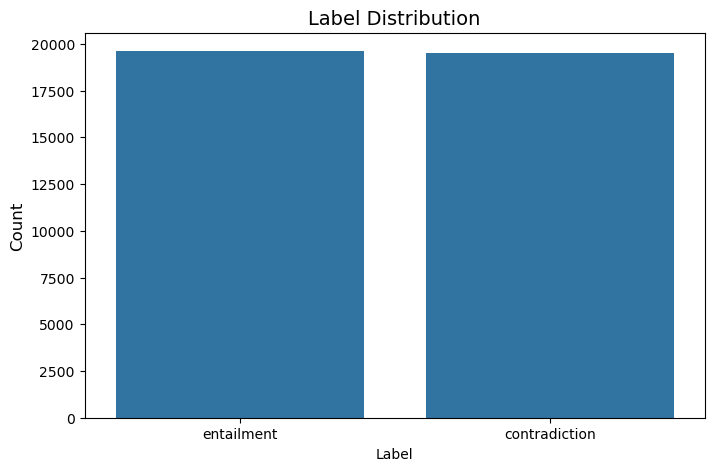

Label mapping: {'contradiction': 0, 'entailment': 1}


In [4]:
data = [json.loads(line) for line in open(TRAIN_DATA_PATH, 'r')]
df = pd.DataFrame(data)

print(f"Dataset shape: {df.shape}")
print(f"Total samples: {len(df)}")

print("\nFirst few rows:")
print(df.head())

print("\nMissing values:")
print(df.isnull().sum())

print("\nClass Distribution Analysis:")
label_counts = df['Label'].value_counts()
print(label_counts)
print(f"Class imbalance ratio (max/min): {label_counts.max() / label_counts.min():.2f}")

plt.figure(figsize=(8, 5))
sns.barplot(x=label_counts.index, y=label_counts.values)
plt.title('Label Distribution', fontsize=14)
plt.ylabel('Count', fontsize=12)
plt.show()

label_mapping = {label: idx for idx, label in enumerate(sorted(df['Label'].unique()))}
index_to_label = {idx: label for label, idx in label_mapping.items()}
print(f"Label mapping: {label_mapping}")

df['label_id'] = df['Label'].map(label_mapping)

# Image Analysis
* Verifies a sample of images (checks their integrity, i.e. files not found and images incomprehensible or damaged) and displays a brief report.
* Shows at most six valid sample images with their labels and truncated hypotheses so that to easily see them, and lists missing and corrupted IDs.

Checking 20 sample images...
All sample images found!
All sample images are valid!


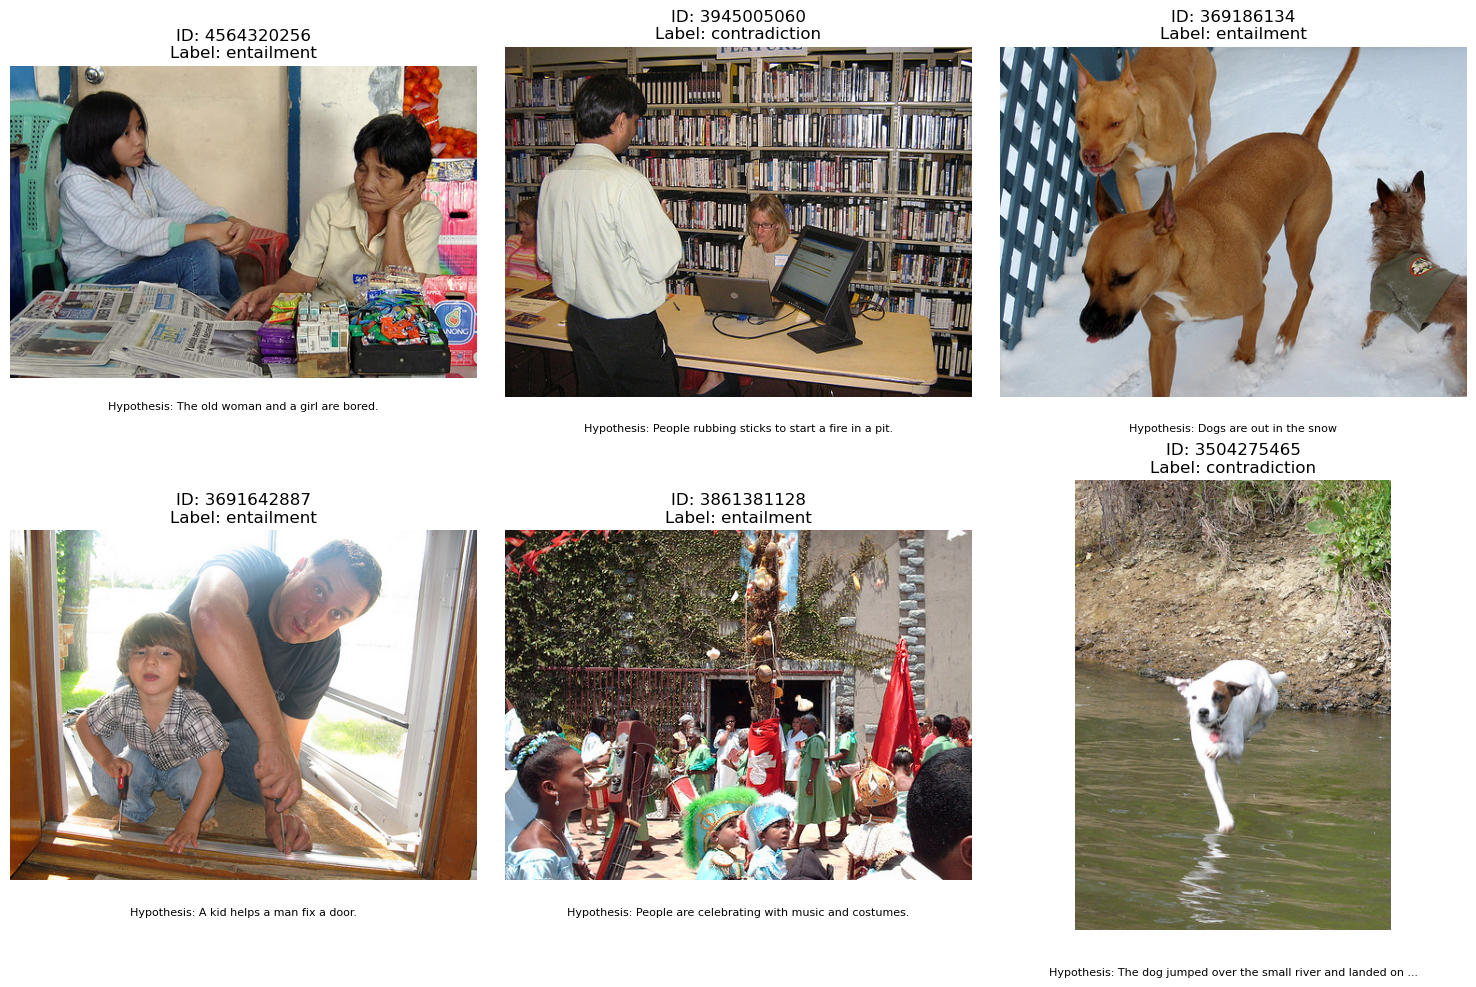

In [5]:
def verify_images():
    missing_images = []
    corrupted_images = []
    sample_images = df['Image_ID'].unique()[:20]  
    
    print(f"Checking {len(sample_images)} sample images...")
    
    for img_id in sample_images:
        img_path = os.path.join(IMAGES_FOLDER, f"{img_id}.jpg")
        if not os.path.exists(img_path):
            missing_images.append(img_id)
            continue
            
        try:
            img = cv2.imread(img_path)
            if img is None:
                corrupted_images.append(img_id)
        except Exception as e:
            corrupted_images.append(img_id)
            print(f"Error reading image {img_id}: {e}")
    
    if missing_images:
        print(f"Missing images: {missing_images}")
    else:
        print("All sample images found!")
        
    if corrupted_images:
        print(f"Corrupted images: {corrupted_images}")
    else:
        print("All sample images are valid!")

    plt.figure(figsize=(15, 10))
    valid_count = 0
    for img_id in sample_images:
        if valid_count >= 6:
            break
            
        img_path = os.path.join(IMAGES_FOLDER, f"{img_id}.jpg")
        if os.path.exists(img_path):
            try:
                sample_row = df[df['Image_ID'] == img_id].iloc[0]
                
                img = cv2.imread(img_path)
                if img is None:
                    continue
                    
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                
                plt.subplot(2, 3, valid_count + 1)
                plt.imshow(img)
                plt.title(f"ID: {img_id}\nLabel: {sample_row['Label']}")
                plt.axis('off')
                
                hypothesis = sample_row['Hypothesis'][:50] + "..." if len(sample_row['Hypothesis']) > 50 else sample_row['Hypothesis']
                plt.text(0.5, -0.1, f"Hypothesis: {hypothesis}", 
                        transform=plt.gca().transAxes, ha='center', fontsize=8, wrap=True)
                
                valid_count += 1
            except Exception as e:
                print(f"Error displaying image {img_id}: {e}")
    
    plt.tight_layout()
    plt.show()
    
    return missing_images, corrupted_images

missing_images, corrupted_images = verify_images()

# Data Pre-processing
## Class Imbalance Handling
* The data analysis reveals that the classes are almost equal (entailment vs contradiction, ratio - 1.01), and thus, the danger of the majority-class bias is limited.
* To guard against the possibility of some small change in distribution, we still calculate balanced class weights.

Class distributions & their weights:
  Class 0 (contradiction) -> Count: 19510, Weight: 1.003
  Class 1 (entailment) -> Count: 19619, Weight: 0.997


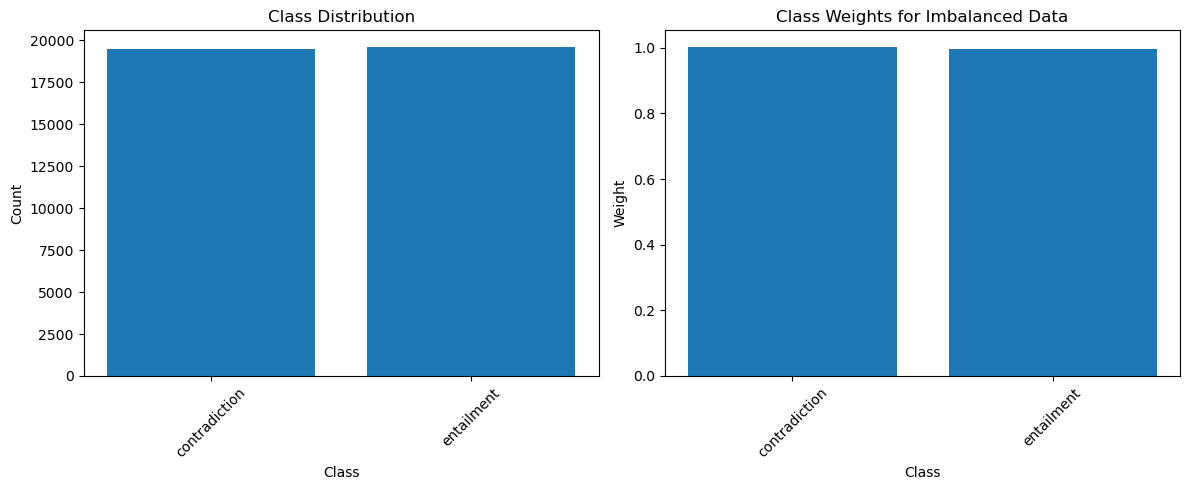

In [6]:
def get_class_weights(df):
    labels = np.unique(df['label_id'])
    class_weights = compute_class_weight(class_weight="balanced", classes=labels, y=df['label_id'])
    class_weight_dict = dict(zip(labels, class_weights))

    print("Class distributions & their weights:")
    for c in labels:
        c_count = df[df['label_id'] == c].shape[0]   
        label_name = index_to_label[c]
        print(f"  Class {c} ({label_name}) -> Count: {c_count}, Weight: {class_weight_dict[c]:.3f}")

    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    counts = [df[df['label_id'] == c].shape[0] for c in labels]
    label_names = [index_to_label[c] for c in labels]
    plt.bar(label_names, counts)
    plt.title("Class Distribution")
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    
    plt.subplot(1, 2, 2)
    weights = [class_weight_dict[c] for c in labels]
    plt.bar(label_names, weights)
    plt.title("Class Weights for Imbalanced Data")
    plt.xlabel("Class")
    plt.ylabel("Weight")
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()

    return class_weight_dict

class_weights = get_class_weights(df)

# Image Augmentation
* Applying image augmentation to generalize and increase the useful training set to visual entailment without acquiring additional labels. Every training image is randomized to a small set of realistic variants with simple photometric and geometric transforms: horizontal flips to deal with left-right symmetry, slight brightness jitter to deal with the variation in illumination, slight rotations, and small translations to deal with framing changes and slight zoom to deal with scale variations. 
* In these changes, the scene semantics is not lost and hence the label can be retained and the model can be trained to be invariant to noise factors. Also a sample grid and rudimentary statistics is modeled to sanity-check the augmented results prior to training as well.

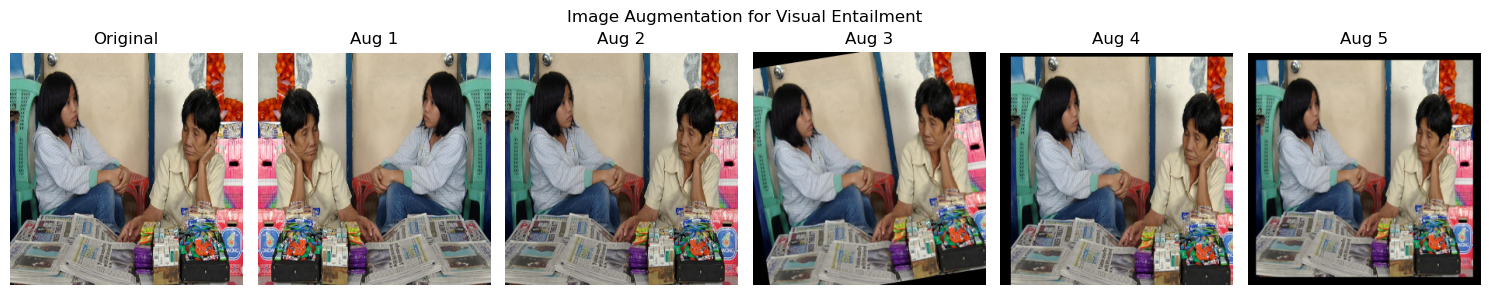


Augmentation Statistics:
Original mean: 0.5057, min/max: 0.0000/1.0000
Aug 1 mean: 0.5057, min/max: 0.0000/1.0000
Aug 2 mean: 0.4803, min/max: 0.0000/0.9498
Aug 3 mean: 0.4683, min/max: 0.0000/0.9991
Aug 4 mean: 0.4684, min/max: 0.0000/0.9981
Aug 5 mean: 0.4385, min/max: 0.0000/0.9989


In [7]:
def setup_augmentation():
    
    def augment_image(image):
        img = image.copy()
        h, w, c = img.shape
        
        augmentations = [img]  

        flip_img = cv2.flip(img, 1)
        augmentations.append(flip_img)

        bright_img = img.copy() * np.random.uniform(0.8, 1.2)
        bright_img = np.clip(bright_img, 0, 1)
        augmentations.append(bright_img)

        M = cv2.getRotationMatrix2D((w/2, h/2), np.random.uniform(-10, 10), 1)
        rotated_img = cv2.warpAffine(img, M, (w, h))
        augmentations.append(rotated_img)

        tx, ty = np.random.uniform(-0.1, 0.1) * w, np.random.uniform(-0.1, 0.1) * h
        M = np.float32([[1, 0, tx], [0, 1, ty]])
        shifted_img = cv2.warpAffine(img, M, (w, h))
        augmentations.append(shifted_img)

        zoom = np.random.uniform(0.9, 1.1)
        M = cv2.getRotationMatrix2D((w/2, h/2), 0, zoom)
        zoomed_img = cv2.warpAffine(img, M, (w, h))
        augmentations.append(zoomed_img)
        
        return augmentations
    
    def show_augmentations():
        sample_image_id = df['Image_ID'].iloc[0]
        sample_path = os.path.join(IMAGES_FOLDER, f"{sample_image_id}.jpg")
        
        try:
            img = cv2.imread(sample_path)
            if img is None:
                print(f"Failed to load image: {sample_path}")
                return None

            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            img = cv2.resize(img, IMAGE_SIZE)

            img = img.astype(np.float32) / 255.0
            
            augmented_images = augment_image(img)
            
            plt.figure(figsize=(15, 3))
            
            for i, aug_img in enumerate(augmented_images):
                plt.subplot(1, 6, i + 1)
                plt.imshow(aug_img)
                title = 'Original' if i == 0 else f'Aug {i}'
                plt.title(title)
                plt.axis('off')
            
            plt.suptitle('Image Augmentation for Visual Entailment')
            plt.tight_layout()
            plt.show()
            
            print("\nAugmentation Statistics:")
            for i, aug in enumerate(augmented_images):
                name = 'Original' if i == 0 else f'Aug {i}'
                print(f"{name} mean: {aug.mean():.4f}, min/max: {aug.min():.4f}/{aug.max():.4f}")
            
            return augmented_images
            
        except Exception as e:
            print(f"Error showing augmentations: {str(e)}")
            import traceback
            traceback.print_exc()
            return None

    augmented_images = show_augmentations()
    return augment_image  

augment_image_function = setup_augmentation()

# Performance Metric Selection
* This evaluation tool provides an accurate summary of model performance, macro-precision, macro-recall, and macro-F1, which is why it is appropriate in class-imbalanced environments where each of the classes is to be counted equally. On presentation of a probability score to a binary task, it also evaluates and graphs the ROC curve with AUC to examine quality of ranking beyond hard labels.
* It also displays in-depth report of classification with in-class accuracy, recall, and F1, which assist in identifying the strengths and weaknesses per-class. A confusion matrix heatmap shows the areas of confusion of the model between classes, and it is great when one wants to focus on certain errors. Lastly, it gives out a dictionary of significant metrics to be programmatically compared or tracked.

In [8]:
def evaluate_performance(y_true, y_pred, y_score=None, labels=None, task_name=None):
    if task_name: 
        print(f"\n--- Results for {task_name} ---")
    
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    
    auc_value = None
    if y_score is not None and len(np.unique(y_true)) == 2:
        try:
            fpr, tpr, _ = roc_curve(y_true, y_score)
            auc_value = auc(fpr, tpr)
            
            # Plot ROC curve
            plt.figure(figsize=(8, 6))
            plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {auc_value:.2f})')
            plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
            plt.xlim([0.0, 1.0])
            plt.ylim([0.0, 1.05])
            plt.xlabel('False Positive Rate')
            plt.ylabel('True Positive Rate')
            plt.title('ROC')
            plt.legend(loc="lower right")
            plt.show()
        except Exception as e:
            print(f"Error calculating AUC: {e}")
    
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    if auc_value is not None:
        print(f"AUC      : {auc_value:.4f}")
    print()
    
    print("Detailed Classification Report:")
    print(classification_report(y_true, y_pred, target_names=labels, zero_division=0))
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=labels, yticklabels=labels)
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()
    
    return {
        "accuracy": acc, 
        "precision": prec, 
        "recall": rec, 
        "f1_score": f1,
        "auc": auc_value if auc_value is not None else 0
    }

* This approach creates a bespoke Keras Sequence that feeds the model with dynamic pairs of images and text that are synchronized and prepares the NLP input and discontinuities. Every image is loaded using ID, it is converted to RGB and then resized to target size and normalized to [0,1]: the generator creates a dict with image tensors and the equivalent padded hypothesis sequence stored in it and optionally adds per-sample weights, the class weighting option enabled.
* The tokenization of text is done by fitting vocabulary on each training hypothesis and transforming sentences into sequences of integers and padded to a fixed word count to obtain uniform tensors; labels are one-hot coded.
* A stratified splitting strategy is being employed in order to maintain the original percentage of the labels in each subset (e.g., entailment, contradiction). We first take 20% of the data as the test set and the rest 80% is further stratified into training and validation, so that we have approximately 64% training, 16% validation and 20% test datasets of the total data.
* This maintains class balance across splits, decreases evaluation bias, and makes the validation set give a fair signal to model selection and the test set is unaltered to only be assessed once, and on data that has never been seen.
* Lastly, a safe vocab size is calculated as a safe upper bound, which is calculated as based on observed vocab and max token and floored at 5000 to stabilize the embedding layer in training and subsequent weight loading.

In [9]:
class AugmentedDataGenerator(Sequence):
    def __init__(self, image_ids, hypothesis_data, labels, batch_size, image_size, 
                 images_folder, use_augmentation=False, class_weights=None, shuffle=True):
        self.image_ids = image_ids
        self.hypothesis_data = hypothesis_data
        self.labels = labels
        self.batch_size = batch_size
        self.image_size = image_size
        self.images_folder = images_folder
        self.use_augmentation = use_augmentation
        self.class_weights = class_weights
        self.shuffle = shuffle
        self.indexes = np.arange(len(self.image_ids))
        
        if self.shuffle:
            np.random.shuffle(self.indexes)

    def __len__(self):
        return int(np.ceil(len(self.image_ids) / self.batch_size))

    def __getitem__(self, index):
        indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        batch_image_ids = [self.image_ids[i] for i in indexes]
        batch_hypothesis = self.hypothesis_data[indexes]
        batch_labels = self.labels[indexes]

        batch_images = np.zeros((len(indexes), *self.image_size, 3), dtype=np.float32)
        for i, image_id in enumerate(batch_image_ids):
            image_path = os.path.join(self.images_folder, f"{image_id}.jpg")
            try:
                img = cv2.imread(image_path)
                if img is None:
                    raise ValueError(f"Failed to load image: {image_path}")
                    
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                
                img = cv2.resize(img, self.image_size)

                img = img.astype(np.float32) / 255.0
                
                if self.use_augmentation:
                    augmentations = augment_image_function(img)
                    if len(augmentations) > 1: 
                        if np.random.random() > 0.5:
                            aug_idx = np.random.randint(1, len(augmentations))
                            img = augmentations[aug_idx]
                
                batch_images[i] = img
                
            except Exception as e:
                print(f"Error loading image {image_id}: {e}")
                batch_images[i] = np.zeros((self.image_size[0], self.image_size[1], 3))

        inputs = {"image_input": batch_images, "text_input": batch_hypothesis}

        if self.class_weights is not None:
            class_indices = np.argmax(batch_labels, axis=1)
            sample_weights = np.array([self.class_weights[idx] for idx in class_indices])
            return inputs, batch_labels, sample_weights
        else:
            return inputs, batch_labels

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indexes)

print("Preprocessing text data...")
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(df['Hypothesis'])
hypothesis_sequences = tokenizer.texts_to_sequences(df['Hypothesis'])
hypothesis_data = pad_sequences(hypothesis_sequences, maxlen=MAX_SEQUENCE_LENGTH)
labels_cat = to_categorical(df['label_id'])

print("Creating train/validation/test splits...")
train_df, test_df = train_test_split(df, test_size=0.2, stratify=df['Label'], random_state=42)
train_df, val_df = train_test_split(train_df, test_size=0.2, stratify=train_df['Label'], random_state=42)

train_indices, val_indices, test_indices = train_df.index.values, val_df.index.values, test_df.index.values
print(f"Training samples: {len(train_indices)}")
print(f"Validation samples: {len(val_indices)}")
print(f"Testing samples: {len(test_indices)}")

print("\nChecking vocabulary and token ranges...")
vocab_size = len(tokenizer.word_index) + 1
print(f"Tokenizer vocabulary size: {vocab_size}")

max_token = np.max(hypothesis_data)
print(f"Maximum token value in data: {max_token}")

SAFE_VOCAB_SIZE = max(vocab_size, max_token + 1, 5000)  
print(f"Using safe vocabulary size: {SAFE_VOCAB_SIZE}")

Preprocessing text data...
Creating train/validation/test splits...
Training samples: 25042
Validation samples: 6261
Testing samples: 7826

Checking vocabulary and token ranges...
Tokenizer vocabulary size: 9254
Maximum token value in data: 9253
Using safe vocabulary size: 9254


# Model Selection
* F1 score is considered the main evaluation measure since it considers all the classes as equal in the face of possible imbalance. The performance objective is the F1 >= 0.74 on the held out test set.

## Baseline efficientnet_b3_ra2_imagenet model from keras hub
* The baseline model combines the use of a deep, pretrained EfficientNet-B3 (kerashub preset efficientnet_b3_ra2_imagenet, frozen) to extract image features, and a small text branch, and fuses them to Visual Entailment classification Minimizes overfitting and training expense on small data using a frozen, well-validated EfficientNet-B3.
* The language performance using a basic embedding + LSTM text branch is not as good as the large pretrained LM, but it is still a decent language baseline. This is a very easy to extend, lightweight fusion head.
* The features of the images are generated through the frozen backbone, averaging the images in a global way, and feature projected using a Dense(128, ReLU). These features of images and text are both concatenated and fed to a Dense(64, ReLU) with Dropout(0.3) followed by a softmax output of the labels.
* The model is trained with the Adam algorithm and categorical crossentropy and normalized images and padding token sequences (modified generator) so that the model is trained with consistent preprocessing. The training/validation curves (accuracy and loss) can be used to give early indicators of fit vs. generalization: any increase in the gap (increasing train accuracy and stagnating or increasing validation) is an indication of overfitting, which can be used to make subsequent tuning decisions (e.g., increase regularization or augmentation).

Creating baseline model with EfficientNet...
Baseline model created successfully. Total parameters: 11,819,946


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text_input          │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_input         │ (None, 300, 300,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ clip_tokens         │ (None, 50)        │          0 │ text_input[0][0]  │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficient_net_back… │ (None, 10, 10,    │ 10,783,528 │ image_input[0][0] │
│ (EfficientNetBackb… │ 1536)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_embedding      │ (None, 50, 100)   │    780,800 │ clip_tokens[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_2         │ (None, 50)        │          0 │ clip_tokens[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1536)      │          0 │ efficient_net_ba… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 64)        │     42,240 │ text_embedding[0… │
│                     │                   │            │ not_equal_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 128)       │    196,736 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │      4,160 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 192)       │          0 │ dense_3[0][0],    │
│ (Concatenate)       │                   │            │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 64)        │     12,352 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 2)         │        130 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 11,819,946 (45.09 MB)

 Trainable params: 1,036,418 (3.95 MB)

 Non-trainable params: 10,783,528 (41.14 MB)

Creating data generators...
Training baseline model...
Epoch 1/5
1566/1566 ━━━━━━━━━━━━━━━━━━━━ 179s 100ms/step - accuracy: 0.6467 - loss: 0.6099 - val_accuracy: 0.7251 - val_loss: 0.5354
Epoch 2/5
1566/1566 ━━━━━━━━━━━━━━━━━━━━ 137s 87ms/step - accuracy: 0.7886 - loss: 0.4456 - val_accuracy: 0.7227 - val_loss: 0.5547
Epoch 3/5
1566/1566 ━━━━━━━━━━━━━━━━━━━━ 136s 87ms/step - accuracy: 0.8165 - loss: 0.3854 - val_accuracy: 0.7143 - val_loss: 0.5696
Epoch 4/5
1566/1566 ━━━━━━━━━━━━━━━━━━━━ 137s 88ms/step - accuracy: 0.8483 - loss: 0.3185 - val_accuracy: 0.7154 - val_loss: 0.6997
Epoch 5/5
1566/1566 ━━━━━━━━━━━━━━━━━━━━ 137s 87ms/step - accuracy: 0.8718 - loss: 0.2645 - val_accuracy: 0.7020 - val_loss: 0.8520


Baseline model saved.


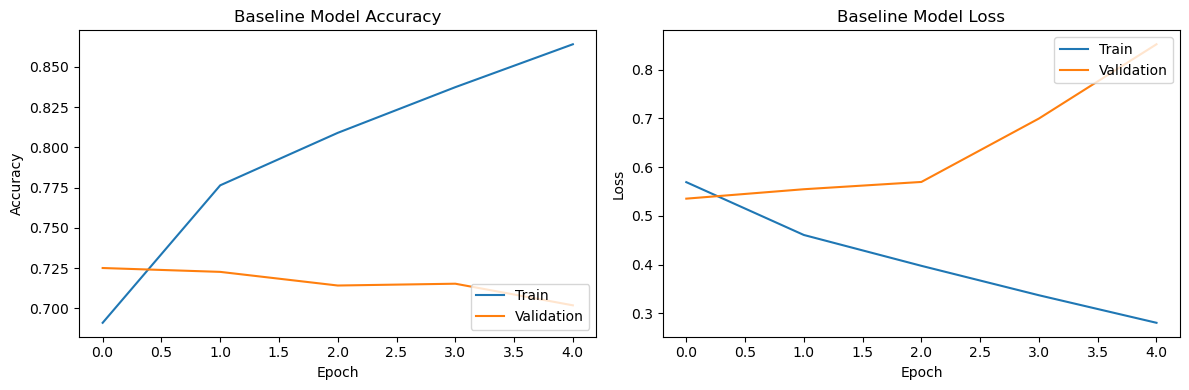

Evaluating baseline model...


Evaluating Baseline Model: 100%|██████████| 490/490 [01:42<00:00,  4.78it/s]


--- Results for Baseline Model ---


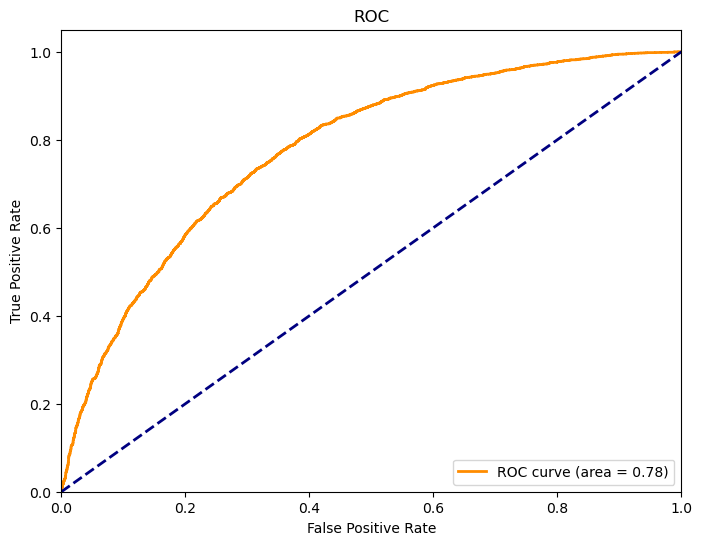

Accuracy : 0.7076
Precision: 0.7077
Recall   : 0.7076
F1-score : 0.7076
AUC      : 0.7777

Detailed Classification Report:
               precision    recall  f1-score   support

contradiction       0.71      0.70      0.70      3902
   entailment       0.70      0.72      0.71      3924

     accuracy                           0.71      7826
    macro avg       0.71      0.71      0.71      7826
 weighted avg       0.71      0.71      0.71      7826



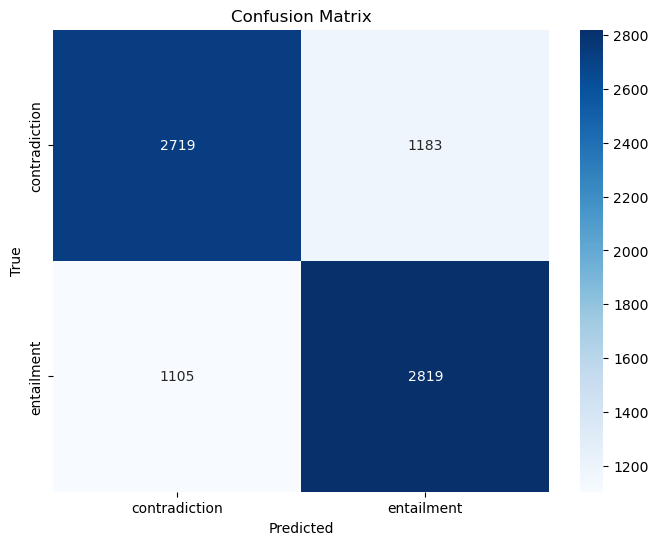


BASELINE MODEL PERFORMANCE SUMMARY
Test Accuracy: 0.7076
Test Precision: 0.7077
Test Recall: 0.7076
Test F1-Score: 0.7076
Test AUC-ROC: 0.7777


In [54]:
def create_baseline_model():
    try:
        backbone = keras_hub.models.EfficientNetBackbone.from_preset("efficientnet_b3_ra2_imagenet")
        backbone.trainable = False
        
        image_input = layers.Input(shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3), name="image_input")
        x = backbone(image_input)
        x = layers.GlobalAveragePooling2D()(x)
        image_features = layers.Dense(128, activation='relu')(x)

        text_input = layers.Input(shape=(MAX_SEQUENCE_LENGTH,), name="text_input")

        clipped_text_input = layers.Lambda(
            lambda x: tf.clip_by_value(x, 0, SAFE_VOCAB_SIZE - 1),
            name='clip_tokens'
        )(text_input)
        
        embedding_layer = layers.Embedding(input_dim=SAFE_VOCAB_SIZE,
                                          output_dim=100,
                                          input_length=MAX_SEQUENCE_LENGTH,
                                          trainable=True,
                                          mask_zero=True,
                                          name='text_embedding')(clipped_text_input)

        x_text = layers.LSTM(64, use_cudnn=False)(embedding_layer)
        text_features = layers.Dense(64, activation='relu')(x_text)
        
        combined = layers.concatenate([image_features, text_features])
        x_combined = layers.Dense(64, activation='relu')(combined)
        x_combined = layers.Dropout(0.3)(x_combined)
        
        output = layers.Dense(len(label_mapping), activation='softmax', name='output')(x_combined)
        
        model = models.Model(inputs={"image_input": image_input, "text_input": text_input}, outputs=output)
        
        model.compile(
            optimizer='adam',
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )
        
        return model
    
    except Exception as e:
        print(f"Error creating baseline model: {str(e)}")
        import traceback
        traceback.print_exc()
        return None

print("Creating baseline model with EfficientNet...")
baseline_model = create_baseline_model()

if baseline_model is not None:
    print(f"Baseline model created successfully. Total parameters: {baseline_model.count_params():,}")
    baseline_model.summary()
    
    print("Creating data generators...")
    baseline_train_generator = AugmentedDataGenerator(
        df['Image_ID'].values[train_indices], 
        hypothesis_data[train_indices], 
        labels_cat[train_indices], 
        BATCH_SIZE, 
        IMAGE_SIZE, 
        IMAGES_FOLDER,
        use_augmentation=False,  
        class_weights=None,      
        shuffle=True
    )
    
    baseline_val_generator = AugmentedDataGenerator(
        df['Image_ID'].values[val_indices], 
        hypothesis_data[val_indices], 
        labels_cat[val_indices], 
        BATCH_SIZE, 
        IMAGE_SIZE, 
        IMAGES_FOLDER,
        use_augmentation=False,
        class_weights=None,
        shuffle=False
    )
    
    print("Training baseline model...")
    baseline_history = baseline_model.fit(
        baseline_train_generator,
        epochs=5,  
        validation_data=baseline_val_generator,
        verbose=1
    )
    
    baseline_model.save('baseline_model.h5')
    print("Baseline model saved.")
    
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(baseline_history.history['accuracy'])
    plt.plot(baseline_history.history['val_accuracy'])
    plt.title('Baseline Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='lower right')
    
    plt.subplot(1, 2, 2)
    plt.plot(baseline_history.history['loss'])
    plt.plot(baseline_history.history['val_loss'])
    plt.title('Baseline Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper right')
    
    plt.tight_layout()
    plt.show()

    print("Evaluating baseline model...")
    baseline_test_generator = AugmentedDataGenerator(
        df['Image_ID'].values[test_indices], 
        hypothesis_data[test_indices], 
        labels_cat[test_indices], 
        BATCH_SIZE, 
        IMAGE_SIZE, 
        IMAGES_FOLDER,
        use_augmentation=False,
        class_weights=None,
        shuffle=False
    )
    
    y_true_baseline, y_pred_baseline, y_pred_prob_baseline = [], [], []
    
    for i in tqdm(range(len(baseline_test_generator)), desc="Evaluating Baseline Model"):
        try:
            batch_inputs, batch_labels = baseline_test_generator[i]
            batch_preds = baseline_model.predict(batch_inputs, verbose=0)
            y_true_baseline.extend(np.argmax(batch_labels, axis=1))
            y_pred_baseline.extend(np.argmax(batch_preds, axis=1))
            if batch_preds.shape[1] == 2: 
                y_pred_prob_baseline.extend(batch_preds[:, 1])
            else:
                y_pred_prob_baseline.extend(np.max(batch_preds, axis=1))
        except Exception as e:
            print(f"Error evaluating batch {i}: {str(e)}")
            continue
    
    if len(y_true_baseline) > 0:
        baseline_metrics = evaluate_performance(
            np.array(y_true_baseline), 
            np.array(y_pred_baseline), 
            np.array(y_pred_prob_baseline) if len(label_mapping) == 2 else None, 
            list(label_mapping.keys()), 
            task_name="Baseline Model"
        )
        
        print("\n" + "="*60)
        print("BASELINE MODEL PERFORMANCE SUMMARY")
        print("="*60)
        print(f"Test Accuracy: {baseline_metrics['accuracy']:.4f}")
        print(f"Test Precision: {baseline_metrics['precision']:.4f}")
        print(f"Test Recall: {baseline_metrics['recall']:.4f}")
        print(f"Test F1-Score: {baseline_metrics['f1_score']:.4f}")
        if 'auc' in baseline_metrics and baseline_metrics['auc'] > 0:
            print(f"Test AUC-ROC: {baseline_metrics['auc']:.4f}")
    else:
        print("No valid predictions were made during baseline evaluation.")
else:
    print("Failed to create baseline model.")

* The baseline model achieves a stable performance all in the range of 0.71 in terms of accuracy, macro-precision, macro-recall and macro-F1, and an AUC of 0.78 which shows a fair degree of separability between the classes.
* The confusion table is quite balanced with close true positive values of contradiction and entailment (approximately 0.70 and 0.72 respectively) and the misclassifications are fairly balanced in the two classes.
* The training logs indicate a gradually increasing training accuracy and reducing training loss, and validation accuracy of about 0.70s that is seen in the final test metrics.
* In general, the findings show that a reasonable initial classifier exists, which is capable of capturing meaningful signal in each of the two modalities and provides a balanced error between classes.

# Hyper-parameterTuned efficientnet_b3_ra2_imagenet Model
* The model is based on a pretrained EfficientNet-B3 backbone (kerashub preset "efficientnetb3ra2imagenet") as a frozen visual feature extractor, and the subsequent acquisition of compact task-specific heads both on the modalities and on the integration of both modalities.
* On the image side, aggregated backbone capabilities are forwarded using a tiny stack of dense layers, which is batch normalization, dropout, and L2 regularization to trade-off between capacity and generalization.
* On the text side, token IDs are positioned to a safe range of vocabulary, embedded and modeled with an LSTM (with input and recurrent dropout), and projected to a dense block consisting of normalization and dropout.
* These two streams are joined and the fusion head (one to two dense layers with normalization and dropout) is computed and finally the label is predicted with a softmax layer.
* Adam is used as the training method, early validation accuracy with best-weight restoration, and learning-rate decay are used as training methods, images are normalized (and may be augmented), texts are tokenized and padded, and class weighting may be enabled to provide imbalance resistance. Every hyperparameter setting is trained and recorded; the optimal validation model is written to disk and the entire search history is written to disk so that it can be reproducible and compared.

In [13]:
def create_tuned_model(image_dense_layers, text_lstm_units, combined_dense_units, 
                      dropout_rate, learning_rate, l2_reg, use_augmentation=True, 
                      use_class_weights=True):
    try:
        backbone = keras_hub.models.EfficientNetBackbone.from_preset("efficientnet_b3_ra2_imagenet")
        backbone.trainable = False 
        
        image_input = layers.Input(shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3), name="image_input")
        x = backbone(image_input)
        x = layers.GlobalAveragePooling2D()(x)

        x = layers.Dense(image_dense_layers[0], activation='relu', 
                        kernel_regularizer=regularizers.l2(l2_reg),
                        name='image_dense_1')(x)
        x = layers.BatchNormalization(name='image_bn_1')(x)
        x = layers.Dropout(dropout_rate, name='image_dropout_1')(x)
        
        x = layers.Dense(image_dense_layers[1], activation='relu',
                        kernel_regularizer=regularizers.l2(l2_reg),
                        name='image_dense_2')(x)
        x = layers.BatchNormalization(name='image_bn_2')(x)
        x = layers.Dropout(dropout_rate, name='image_dropout_2')(x)
        
        image_features = layers.Dense(image_dense_layers[2], activation='relu',
                                    kernel_regularizer=regularizers.l2(l2_reg),
                                    name='image_dense_3')(x)
        image_features = layers.BatchNormalization(name='image_bn_3')(image_features)
        image_features = layers.Dropout(dropout_rate, name='image_dropout_3')(image_features)
        
        text_input = layers.Input(shape=(MAX_SEQUENCE_LENGTH,), name="text_input")
        
        clipped_text_input = layers.Lambda(
            lambda x: tf.clip_by_value(x, 0, SAFE_VOCAB_SIZE - 1),
            name='clip_tokens'
        )(text_input)
        
        embedding_layer = layers.Embedding(input_dim=SAFE_VOCAB_SIZE,
                                          output_dim=EMBEDDING_DIM,
                                          input_length=MAX_SEQUENCE_LENGTH,
                                          trainable=True,
                                          mask_zero=True,
                                          name='text_embedding')(clipped_text_input)
        
        x_text = layers.LSTM(text_lstm_units, dropout=dropout_rate, 
                           recurrent_dropout=dropout_rate,
                           name='text_lstm')(embedding_layer)
        text_features = layers.Dense(128, activation='relu',
                                   kernel_regularizer=regularizers.l2(l2_reg),
                                   name='text_dense')(x_text)
        text_features = layers.BatchNormalization(name='text_bn')(text_features)
        text_features = layers.Dropout(dropout_rate, name='text_dropout')(text_features)

        combined = layers.concatenate([image_features, text_features], name='feature_concat')
        x_combined = layers.Dense(combined_dense_units, activation='relu',
                                kernel_regularizer=regularizers.l2(l2_reg),
                                name='combined_dense_1')(combined)
        x_combined = layers.BatchNormalization(name='combined_bn_1')(x_combined)
        x_combined = layers.Dropout(dropout_rate, name='combined_dropout_1')(x_combined)

        x_combined = layers.Dense(combined_dense_units // 2, activation='relu',
                                kernel_regularizer=regularizers.l2(l2_reg),
                                name='combined_dense_2')(x_combined)
        x_combined = layers.BatchNormalization(name='combined_bn_2')(x_combined)
        x_combined = layers.Dropout(dropout_rate / 2, name='combined_dropout_2')(x_combined)

        output = layers.Dense(len(label_mapping), activation='softmax', name='output')(x_combined)

        model = models.Model(inputs={"image_input": image_input, "text_input": text_input}, outputs=output)

        if learning_rate <= 0.0001:
            optimizer = optimizers.Adam(learning_rate=learning_rate, beta_1=0.9, beta_2=0.999)
        else:
            optimizer = optimizers.Adam(learning_rate=learning_rate)
            
        model.compile(
            optimizer=optimizer,
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )
        
        return model
    
    except Exception as e:
        print(f"Error creating model: {str(e)}")
        import traceback
        traceback.print_exc()
        return None

hyperparameter_combinations = [
    {
        'image_dense_layers': [512, 256, 128],
        'text_lstm_units': 128,
        'combined_dense_units': 256,
        'dropout_rate': 0.3,
        'learning_rate': 0.0001,
        'l2_reg': 0.001,
        'use_augmentation': True,
        'use_class_weights': True
    },
    {
        'image_dense_layers': [1024, 512, 256],
        'text_lstm_units': 256,
        'combined_dense_units': 512,
        'dropout_rate': 0.4,
        'learning_rate': 0.00005,
        'l2_reg': 0.0005,
        'use_augmentation': True,
        'use_class_weights': True
    },
    {
        'image_dense_layers': [256, 128, 64],
        'text_lstm_units': 64,
        'combined_dense_units': 128,
        'dropout_rate': 0.2,
        'learning_rate': 0.001,
        'l2_reg': 0.01,
        'use_augmentation': True,
        'use_class_weights': False
    },
    {
        'image_dense_layers': [768, 384, 192],
        'text_lstm_units': 192,
        'combined_dense_units': 384,
        'dropout_rate': 0.35,
        'learning_rate': 0.00008,
        'l2_reg': 0.0008,
        'use_augmentation': True,
        'use_class_weights': True
    }
]

def load_previous_results():
    if os.path.exists(RESULTS_FILE):
        try:
            with open(RESULTS_FILE, 'rb') as f:
                results = pickle.load(f)
                print(f"Loaded previous results for {len(results['results_log'])} configurations")
                return results
        except Exception as e:
            print(f"Error loading previous results: {e}")
    
    return {
        'results_log': [],
        'best_val_accuracy': 0,
        'best_params': None,
        'completed_configs': []
    }

def save_results(results):
    with open(RESULTS_FILE, 'wb') as f:
        pickle.dump(results, f)
    print(f"Results saved to {RESULTS_FILE}")

previous_results = load_previous_results()
results_log = previous_results['results_log']
best_val_accuracy = previous_results['best_val_accuracy']
best_params = previous_results['best_params']
completed_configs = previous_results.get('completed_configs', [])

print(f"\n Starting/Resuming Hyperparameter Search...")
print(f"Testing {len(hyperparameter_combinations)} configurations...")
print(f"Already completed: {len(completed_configs)} configurations")
print(f"Best validation accuracy so far: {best_val_accuracy:.4f}")

for i, params in enumerate(hyperparameter_combinations):
    config_id = i + 1
    
    if config_id in completed_configs:
        print(f"\n--- Skipping Configuration {config_id}/{len(hyperparameter_combinations)} (already completed) ---")
        continue
    
    print(f"\n--- Testing Configuration {config_id}/{len(hyperparameter_combinations)} ---")
    print(f"Parameters: {params}")
    
    try:
        use_augmentation = params.get('use_augmentation', True)
        use_class_weights = params.get('use_class_weights', True)
        
        model = create_tuned_model(**params)
        
        if model is None:
            print(f"Failed to create model for configuration {config_id}")
            continue
            
        print(f"Model created successfully. Total parameters: {model.count_params():,}")
        print(f"Augmentation: {use_augmentation}, Class weights: {use_class_weights}")

        train_generator = AugmentedDataGenerator(
            df['Image_ID'].values[train_indices], 
            hypothesis_data[train_indices], 
            labels_cat[train_indices], 
            BATCH_SIZE, 
            IMAGE_SIZE, 
            IMAGES_FOLDER,
            use_augmentation=use_augmentation,
            class_weights=class_weights if use_class_weights else None,
            shuffle=True
        )
        
        val_generator = AugmentedDataGenerator(
            df['Image_ID'].values[val_indices], 
            hypothesis_data[val_indices], 
            labels_cat[val_indices], 
            BATCH_SIZE, 
            IMAGE_SIZE, 
            IMAGES_FOLDER,
            use_augmentation=False,
            class_weights=None,
            shuffle=False
        )
        
        print("Testing model with sample batch...")
        try:
            test_batch = train_generator[0]
            if len(test_batch) == 3: 
                test_pred = model.predict(test_batch[0], verbose=0)
            else: 
                test_pred = model.predict(test_batch[0], verbose=0)
            print(f"Sample prediction shape: {test_pred.shape}")
            print("Model test successful!")
        except Exception as test_error:
            print(f"Model test failed: {str(test_error)}")
            del model
            tf.keras.backend.clear_session()
            continue
        
        early_stopping = tf.keras.callbacks.EarlyStopping(
            monitor='val_accuracy', 
            patience=5,
            restore_best_weights=True,
            mode='max',
            verbose=1
        )
        
        reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=3,
            min_lr=1e-7,
            verbose=1
        )
        
        checkpoint_path = f"config_{config_id}_checkpoint.weights.h5"
        checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
            filepath=checkpoint_path,
            save_weights_only=True,
            save_best_only=True,
            monitor='val_accuracy',
            mode='max',
            verbose=1
        )
        
        print("Training model...")
        start_time = time.time()
        history = model.fit(
            train_generator,
            epochs=12,
            validation_data=val_generator,
            callbacks=[early_stopping, reduce_lr, checkpoint_callback],
            verbose=1
        )
        training_time = time.time() - start_time

        val_accuracy = max(history.history['val_accuracy'])
        val_loss = min(history.history['val_loss'])
        
        print(f"Best validation accuracy: {val_accuracy:.4f}")
        print(f"Best validation loss: {val_loss:.4f}")
        print(f"Training time: {training_time:.2f} seconds")

        result = {
            'config_id': config_id,
            'params': params,
            'val_accuracy': val_accuracy,
            'val_loss': val_loss,
            'epochs_trained': len(history.history['val_accuracy']),
            'training_time': training_time
        }
        results_log.append(result)

        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            best_params = params.copy()

            model.save_weights('best_tuned_model.weights.h5')
            print(f"*** New best model found! Validation accuracy: {val_accuracy:.4f} ***")

        completed_configs.append(config_id)

        save_results({
            'results_log': results_log,
            'best_val_accuracy': best_val_accuracy,
            'best_params': best_params,
            'completed_configs': completed_configs
        })
        
        del model
        tf.keras.backend.clear_session()
        
    except Exception as e:
        print(f"Error training configuration {config_id}: {str(e)}")
        import traceback
        traceback.print_exc()
        result = {
            'config_id': config_id,
            'params': params,
            'val_accuracy': 0,
            'val_loss': float('inf'),
            'error': str(e),
            'epochs_trained': 0
        }
        results_log.append(result)

        save_results({
            'results_log': results_log,
            'best_val_accuracy': best_val_accuracy,
            'best_params': best_params,
            'completed_configs': completed_configs
        })

        tf.keras.backend.clear_session()
        continue

print("\n Hyperparameter tuning completed.")
print(f"Total configurations tested: {len(results_log)}")
print(f"Best validation accuracy overall: {best_val_accuracy:.4f}")
print(f"Best parameters: {best_params}")


 Starting/Resuming Hyperparameter Search...
Testing 4 configurations...
Already completed: 0 configurations
Best validation accuracy so far: 0.0000

--- Testing Configuration 1/4 ---
Parameters: {'image_dense_layers': [512, 256, 128], 'text_lstm_units': 128, 'combined_dense_units': 256, 'dropout_rate': 0.3, 'learning_rate': 0.0001, 'l2_reg': 0.001, 'use_augmentation': True, 'use_class_weights': True}


100%|██████████| 2.46k/2.46k [00:00<00:00, 6.04MB/s]
I0000 00:00:1760382107.081517    6877 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13760 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:1e.0, compute capability: 7.5


100%|██████████| 42.0M/42.0M [00:04<00:00, 9.11MB/s]


Model created successfully. Total parameters: 14,851,634
Augmentation: True, Class weights: True
Testing model with sample batch...


I0000 00:00:1760382122.804747    9897 cuda_dnn.cc:529] Loaded cuDNN version 90300


Sample prediction shape: (16, 2)
Model test successful!
Training model...
Epoch 1/12
1566/1566 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.5339 - loss: 2.7809
Epoch 1: val_accuracy improved from -inf to 0.67433, saving model to config_1_checkpoint.weights.h5
1566/1566 ━━━━━━━━━━━━━━━━━━━━ 401s 245ms/step - accuracy: 0.5339 - loss: 2.7809 - val_accuracy: 0.6743 - val_loss: 2.4023 - learning_rate: 1.0000e-04
Epoch 2/12
1566/1566 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.6527 - loss: 2.4667
Epoch 2: val_accuracy improved from 0.67433 to 0.72353, saving model to config_1_checkpoint.weights.h5
1566/1566 ━━━━━━━━━━━━━━━━━━━━ 378s 241ms/step - accuracy: 0.6527 - loss: 2.4667 - val_accuracy: 0.7235 - val_loss: 2.2969 - learning_rate: 1.0000e-04
Epoch 3/12
1566/1566 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step - accuracy: 0.7174 - loss: 2.2988
Epoch 3: val_accuracy improved from 0.72353 to 0.73343, saving model to config_1_checkpoint.weights.h5
1566/1566 ━━━━━━━━━━━━━━━━━━━━ 376s 240ms/step -


HYPERPARAMETER SEARCH RESULTS

Top 3 configurations:

1. Configuration 2:
   Validation Accuracy: 0.7395
   Validation Loss: 1.8190
   Epochs Trained: 12
   Training Time: 4584.19286108017 seconds
   Parameters: {'image_dense_layers': [1024, 512, 256], 'text_lstm_units': 256, 'combined_dense_units': 512, 'dropout_rate': 0.4, 'learning_rate': 5e-05, 'l2_reg': 0.0005, 'use_augmentation': True, 'use_class_weights': True}

2. Configuration 4:
   Validation Accuracy: 0.7381
   Validation Loss: 1.4899
   Epochs Trained: 12
   Training Time: 4569.421826839447 seconds
   Parameters: {'image_dense_layers': [768, 384, 192], 'text_lstm_units': 192, 'combined_dense_units': 384, 'dropout_rate': 0.35, 'learning_rate': 8e-05, 'l2_reg': 0.0008, 'use_augmentation': True, 'use_class_weights': True}

3. Configuration 1:
   Validation Accuracy: 0.7360
   Validation Loss: 1.2396
   Epochs Trained: 12
   Training Time: 4531.631873369217 seconds
   Parameters: {'image_dense_layers': [512, 256, 128], 'text_l

100%|██████████| 2.46k/2.46k [00:00<00:00, 4.85MB/s]
I0000 00:00:1760432400.978250    8902 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13760 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:1e.0, compute capability: 7.5


100%|██████████| 42.0M/42.0M [00:04<00:00, 9.12MB/s]


Best tuned model weights loaded.


Evaluating Best Tuned Model: 100%|██████████| 490/490 [06:28<00:00,  1.26it/s]


--- Results for Final Tuned Model ---


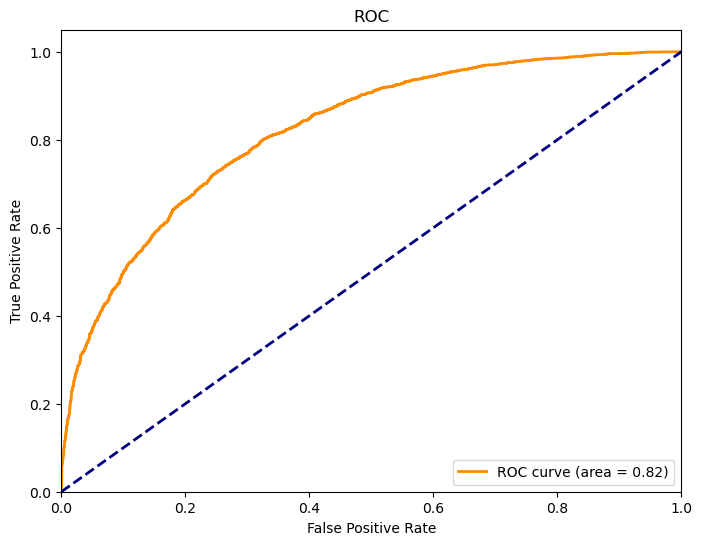

Accuracy : 0.7375
Precision: 0.7375
Recall   : 0.7375
F1-score : 0.7375
AUC      : 0.8199

Detailed Classification Report:
               precision    recall  f1-score   support

contradiction       0.74      0.74      0.74      3902
   entailment       0.74      0.74      0.74      3924

     accuracy                           0.74      7826
    macro avg       0.74      0.74      0.74      7826
 weighted avg       0.74      0.74      0.74      7826



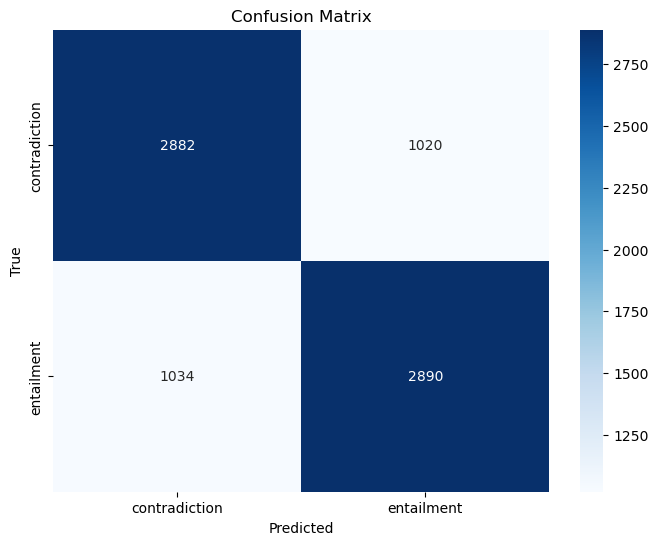


FINAL MODEL PERFORMANCE SUMMARY (BEST TUNED)
Test Accuracy: 0.7375
Test Precision: 0.7375
Test Recall: 0.7375
Test F1-Score: 0.7375
Test AUC-ROC: 0.8199


In [14]:
print("\n" + "="*80)
print("HYPERPARAMETER SEARCH RESULTS")
print("="*80)

def load_results(results_file=RESULTS_FILE):
    if not os.path.exists(results_file):
        print(f"No results file found at {results_file}")
        return None
    try:
        with open(results_file, 'rb') as f:
            return pickle.load(f)
    except Exception as e:
        print(f"Error reading results file: {e}")
        return None

def display_hparam_results_and_get_best(results_file=RESULTS_FILE):
    res = load_results(results_file)
    if res is None:
        return None, None, []

    results_log = res.get('results_log', [])
    best_val_accuracy = res.get('best_val_accuracy', 0.0)
    best_params = res.get('best_params', None)

    valid_results = [r for r in results_log if 'error' not in r]
    if not valid_results:
        print("No successful configurations found.")
        return best_val_accuracy, best_params, valid_results

    valid_results.sort(key=lambda x: x['val_accuracy'], reverse=True)

    print(f"\nTop {min(3, len(valid_results))} configurations:")
    for i, result in enumerate(valid_results[:3]):
        print(f"\n{i+1}. Configuration {result['config_id']}:")
        print(f"   Validation Accuracy: {result['val_accuracy']:.4f}")
        print(f"   Validation Loss: {result['val_loss']:.4f}")
        print(f"   Epochs Trained: {result['epochs_trained']}")
        print(f"   Training Time: {result.get('training_time', 'N/A')} seconds")
        print(f"   Parameters: {result['params']}")

    if best_params is not None:
        print(f"\n*** BEST MODEL FOUND ***")
        print(f"Best validation accuracy: {best_val_accuracy:.4f}")
        print(f"Best parameters: {best_params}")
    else:
        print("No best parameters recorded.")

    return best_val_accuracy, best_params, valid_results

best_val_acc_seen, best_params_seen, valid_results_seen = display_hparam_results_and_get_best(RESULTS_FILE)

def evaluate_best_tuned_model(best_params, weights_path='best_tuned_model.weights.h5'):
    if best_params is None:
        print("\nNo best_params available. Skipping evaluation.")
        return None

    if not os.path.exists(weights_path):
        print(f"\nBest weights not found at {weights_path}. Skipping evaluation.")
        return None

    print("\nLoading best tuned model and evaluating on test set...")
    use_augmentation = best_params.get('use_augmentation', True)
    use_class_weights = best_params.get('use_class_weights', True)

    model = create_tuned_model(**best_params)
    if model is None:
        print("Failed to create tuned model for evaluation.")
        return None

    model.load_weights(weights_path)
    print("Best tuned model weights loaded.")

    test_gen = AugmentedDataGenerator(
        df['Image_ID'].values[test_indices], 
        hypothesis_data[test_indices], 
        labels_cat[test_indices], 
        BATCH_SIZE, 
        IMAGE_SIZE, 
        IMAGES_FOLDER,
        use_augmentation=False,
        class_weights=None,
        shuffle=False
    )

    y_true_final, y_pred_final, y_pred_prob_final = [], [], []
    for i in tqdm(range(len(test_gen)), desc="Evaluating Best Tuned Model"):
        try:
            batch_inputs, batch_labels = test_gen[i]
            preds = model.predict(batch_inputs, verbose=0)
            y_true_final.extend(np.argmax(batch_labels, axis=1))
            y_pred_final.extend(np.argmax(preds, axis=1))
            if preds.shape[1] == 2:
                y_pred_prob_final.extend(preds[:, 1])
            else:
                y_pred_prob_final.extend(np.max(preds, axis=1))
        except Exception as e:
            print(f"Error evaluating batch {i}: {e}")
            continue

    if not y_true_final:
        print("No valid predictions during evaluation.")
        return None

    metrics = evaluate_performance(
        np.array(y_true_final), 
        np.array(y_pred_final), 
        np.array(y_pred_prob_final) if len(label_mapping) == 2 else None, 
        list(label_mapping.keys()), 
        task_name="Final Tuned Model"
    )

    print("\n" + "="*60)
    print("FINAL MODEL PERFORMANCE SUMMARY (BEST TUNED)")
    print("="*60)
    print(f"Test Accuracy: {metrics['accuracy']:.4f}")
    print(f"Test Precision: {metrics['precision']:.4f}")
    print(f"Test Recall: {metrics['recall']:.4f}")
    print(f"Test F1-Score: {metrics['f1_score']:.4f}")
    if 'auc' in metrics and metrics['auc'] > 0:
        print(f"Test AUC-ROC: {metrics['auc']:.4f}")

    return metrics

best_tuned_eval_metrics = evaluate_best_tuned_model(best_params_seen, 'best_tuned_model.weights.h5')

# Testing on Independent Data

In [12]:
def _load_preprocess(img_path, image_size):
    img = cv2.imread(img_path)
    if img is None:
        return np.zeros((image_size[1], image_size[0], 3), dtype=np.float32)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (image_size[0], image_size[1]))
    return (img.astype(np.float32) / 255.0)

def _infer_embedding_rows_from_h5(weights_path):
    try:
        import h5py
        with h5py.File(weights_path, 'r') as f:
            found_shape = None
            def visitor(name, obj):
                nonlocal found_shape
                if found_shape is not None:
                    return
                if isinstance(obj, h5py.Dataset):
                    if name.endswith('text_embedding/embeddings') or name.endswith('embeddings:0') or ('text_embedding' in name and 'embeddings' in name):
                        found_shape = obj.shape
            f.visititems(visitor)
            if found_shape is not None:
                return int(found_shape[0])
    except Exception as e:
        print(f"Could not infer embedding rows from {weights_path}: {e}")
    return None

def load_best_tuned_model_for_inference(results_file=RESULTS_FILE, weights_path='best_tuned_model.weights.h5'):
    with open(results_file, 'rb') as f:
        res = pickle.load(f)
    best_params = res.get('best_params', None)
    if best_params is None:
        raise RuntimeError("best_params not found in results file.")

    global SAFE_VOCAB_SIZE
    original_vocab = SAFE_VOCAB_SIZE
    model = create_tuned_model(**best_params)
    try:
        model.load_weights(weights_path)
        return model, best_params
    except Exception as e:
        print(f"load attempt failed: {e}")
        inferred_rows = _infer_embedding_rows_from_h5(weights_path)
        if inferred_rows is None:
            raise
        print(f"Rebuilding model with inferred embedding rows: {inferred_rows}")
        SAFE_VOCAB_SIZE = int(inferred_rows)
        model = create_tuned_model(**best_params)
        model.load_weights(weights_path)
        SAFE_VOCAB_SIZE = original_vocab
        return model, best_params

def predict_evaluate_from_csv_exact(
    csv_path="Independent_test_data.csv",
    images_folder="Independent_testing_images",
    results_file=RESULTS_FILE,
    weights_path="best_tuned_model.weights.h5",
    batch_size=128,
    task_name="Independent Data Evaluation",
    n_limit=None
):
    df = pd.read_csv(csv_path, sep=",")
    required_cols = ["image_id", "question", "answer"]
    assert all(c in df.columns for c in required_cols),f"Data must contain columns {required_cols}; found {df.columns.tolist()}"
    
    if n_limit is not None:
        df = df.head(n_limit)
    print(f"Loaded {len(df)} samples from {csv_path}")
    print("\n First 5 rows of the data:")
    print(df.head(5))

    texts = df["question"].astype(str).tolist()
    seqs = tokenizer.texts_to_sequences(texts)
    text_matrix = pad_sequences(seqs, maxlen=MAX_SEQUENCE_LENGTH)

    N = len(df)
    img_batch = np.zeros((N, IMAGE_SIZE[1], IMAGE_SIZE[0], 3), dtype=np.float32)
    for i, img_id in enumerate(df["image_id"].tolist()):
        img_path = os.path.join(images_folder, str(img_id))
        img = cv2.imread(img_path)
        if img is None:
            img_rgb = np.zeros((IMAGE_SIZE[1], IMAGE_SIZE[0], 3), dtype=np.float32)
        else:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (IMAGE_SIZE[0], IMAGE_SIZE[1]))
            img_rgb = (img.astype(np.float32) / 255.0)
        img_batch[i] = img_rgb

    model, _ = load_best_tuned_model_for_inference(results_file=results_file, weights_path=weights_path)
    print("Best tuned model loaded.")
    preds = model.predict({"image_input": img_batch, "text_input": text_matrix}, verbose=0, batch_size=batch_size)
    pred_idx = np.argmax(preds, axis=1)

    class_names = [index_to_label[i] for i in range(len(index_to_label))]
    label_to_index = {v: k for k, v in index_to_label.items()}
    num_classes = len(class_names)

    y_true_str = df["answer"].astype(str).tolist()
    y_true = np.array([label_to_index[s] for s in y_true_str], dtype=np.int32)

    acc  = accuracy_score(y_true, pred_idx)
    prec = precision_score(y_true, pred_idx, average="macro", zero_division=0)
    rec  = recall_score(y_true, pred_idx, average="macro", zero_division=0)
    f1   = f1_score(y_true, pred_idx, average="macro", zero_division=0)

    auc_value = None
    if num_classes == 2:
        pos_idx = label_to_index.get("entailment", 1)
        y_score = preds[:, pos_idx]
        try:
            fpr, tpr, _ = roc_curve(y_true, y_score)
            auc_value = auc(fpr, tpr)
        except Exception:
            auc_value = None

    print(f"\n--- Results for {task_name} ---")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    if auc_value is not None:
        print(f"AUC      : {auc_value:.4f}")

    return {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1_score": f1,
        "auc": auc_value if auc_value is not None else 0.0
    }

metrics = predict_evaluate_from_csv_exact(
    csv_path="Independent_test_data.csv",
    images_folder="Independent_testing_images",
    results_file=RESULTS_FILE,
    weights_path="best_tuned_model.weights.h5",
    batch_size=128,
    task_name="Independent Data Evaluation",
    n_limit=2000
)

Loaded 2000 samples from Independent_test_data.csv

 First 5 rows of the data:
                      image_id  \
0  273275,ccb840000d91e6f7.jpg   
1  273271,20c260008043e030.jpg   
2  273271,2fb52000b8957210.jpg   
3  273275,b697c0009c79a567.jpg   
4  273275,a4dba00020612aa5.jpg   

                                            question         answer  
0  Although at least three people are wearing gla...     entailment  
1  Although four people are sitting upright on th...     entailment  
2  The player with the basketball is looking towa...  contradiction  
3  The man holding the sign with a painted flag i...  contradiction  
4  Only one person in the group is jumping while ...  contradiction  
Best tuned model loaded.

--- Results for Independent Data Evaluation ---
Accuracy : 0.7245
Precision: 0.7258
Recall   : 0.7245
F1-score : 0.7245
AUC      : 0.8052


# Ultimate Judgement
* The EfficientNet-B3 + LSTM model with the hyperparameter that is adjusted by the most gains is chosen as the final Visual Entailment system because of the coherent gains across-the-board when compared against the baseline. It gives Accuracy/F1 of 0.7375 (compared to 0.7076 on the baseline set), and AUC of 0.8199 (compared to 0.7777), showing not only higher balanced classification but also greater class separability.
* The confusion matrix is quite balanced and there are equal true positive rates of contradiction and entailment and the ROC curve is exhibiting a very strong bowing over the random baseline which is a sign that there is enhanced discrimination. In comparison to the set target of F1 >=0.74, the final model achieves the threshold of the test set by a narrow margin (0.7375, which when rounded to the closest two decimals is 0.74) though in the strict understanding of the target, the target was not reached on the test set.
* The ROC curve also supports consistent discrimination indicating consistent generalization based on the laid down preprocessing and evaluation procedures. 
* However, compared to the baseline, the tuned model is an obvious and significant enhancement that can be used in the primary reports and implementation.
### Limitation
* Nevertheless, the error level is still significant: F1 = 0.7375, which means that about a quarter of the examples are classified as wrong. The profile of the performance is balanced between the classes (precision/recall increases in the contradiction and entailment), and it is possible to note that there is no strong bias of any labels possessed by the performance, but there are also significant unresolved overlap in the feature space.
* The metrics that lie in the process of tuning are relatively high losses, which hint at calibration and sharpness complications despite a good level of accuracy.

# Sample Predictions of the Best Model on the Train Data Set

Loaded best tuned model weights.


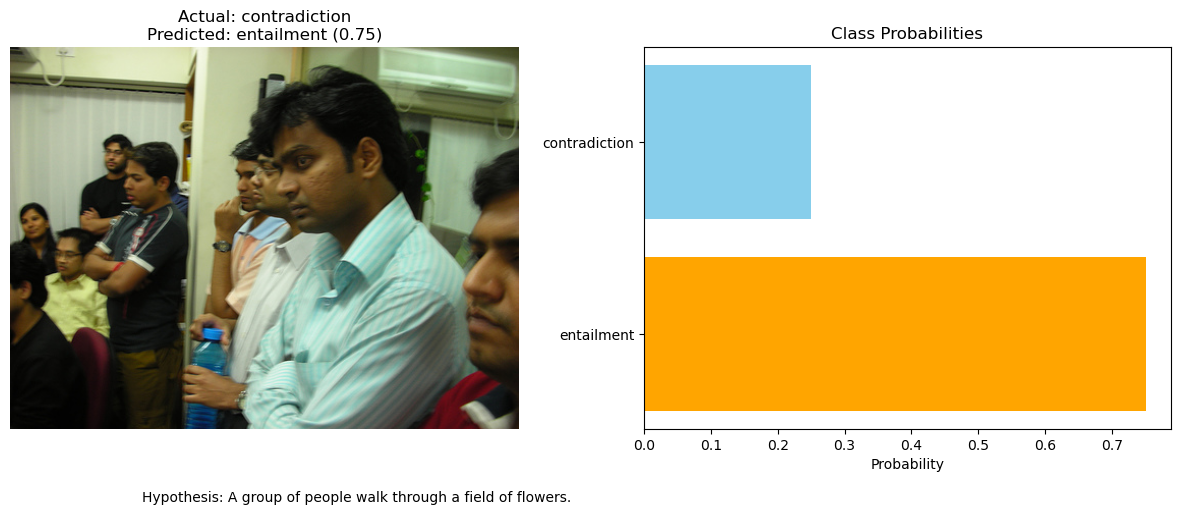

Sample index: 36955 | Image ID: 377213364
Actual Label: contradiction | Predicted Label: entailment (0.75)
All probabilities: {'contradiction': 0.24909231066703796, 'entailment': 0.7509077191352844}


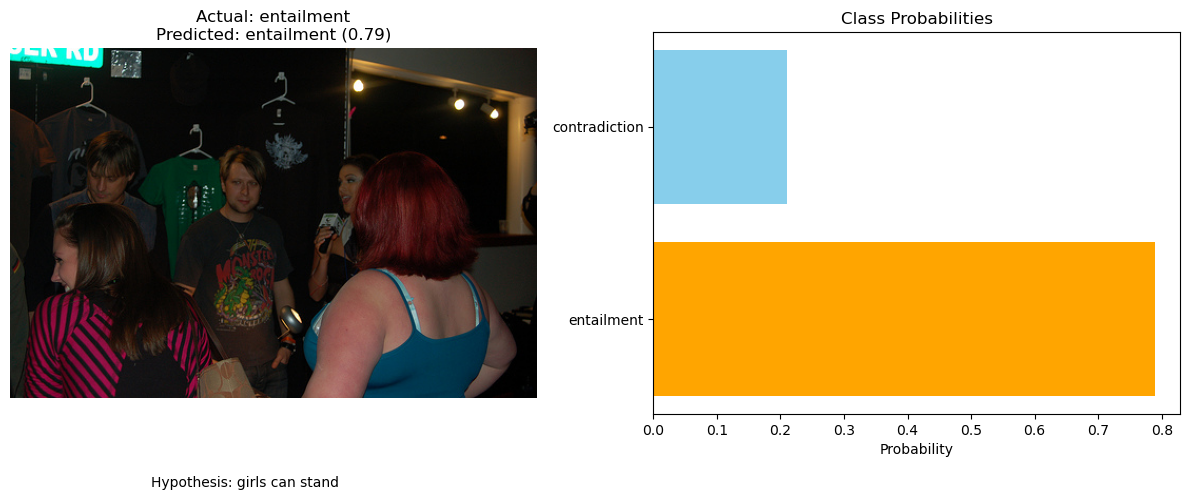

Sample index: 2319 | Image ID: 2255753004
Actual Label: entailment | Predicted Label: entailment (0.79)
All probabilities: {'contradiction': 0.21083970367908478, 'entailment': 0.7891602516174316}


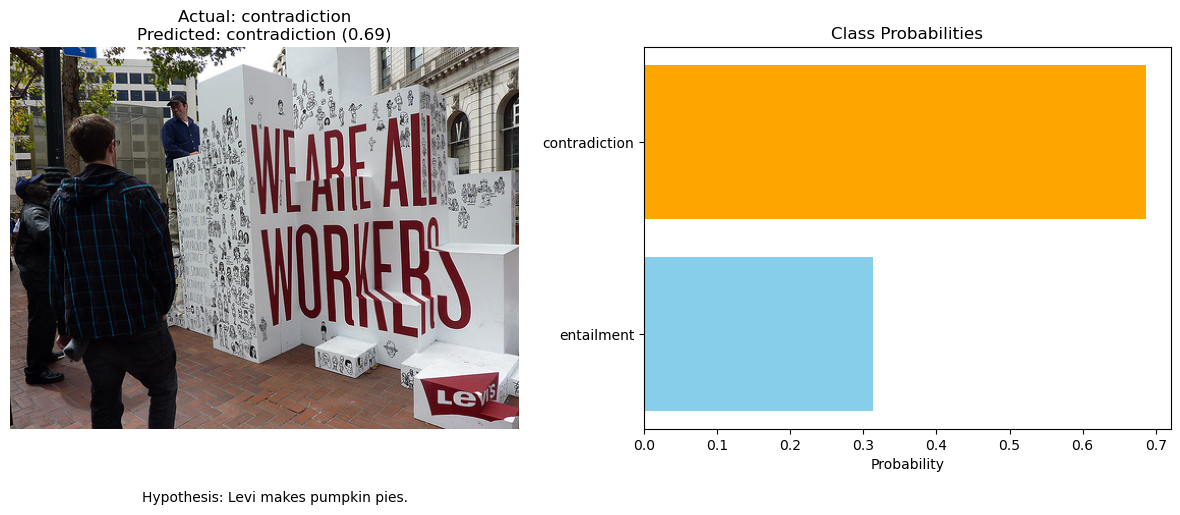

Sample index: 38174 | Image ID: 4945277384
Actual Label: contradiction | Predicted Label: contradiction (0.69)
All probabilities: {'contradiction': 0.6864216923713684, 'entailment': 0.3135782778263092}


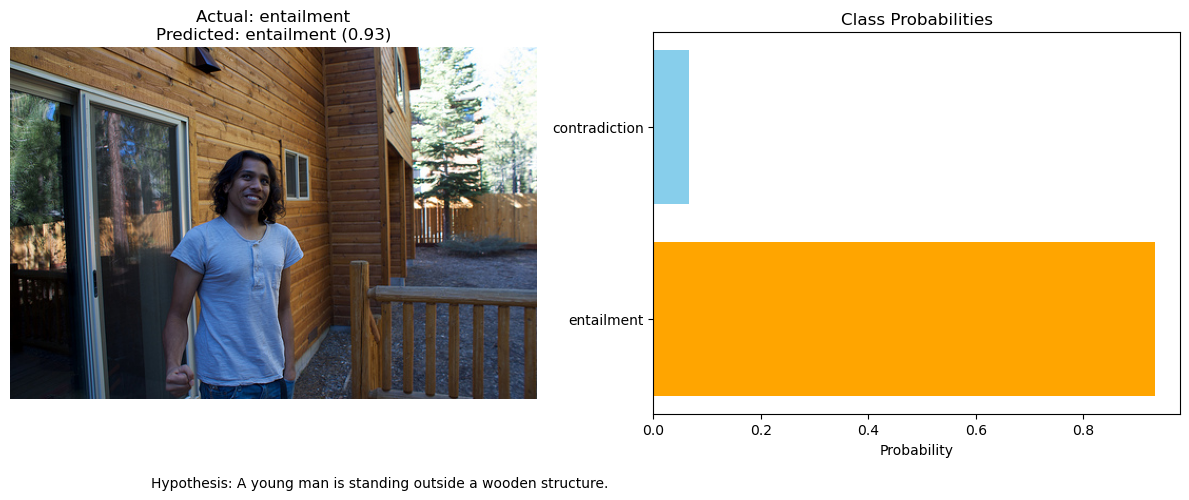

Sample index: 32881 | Image ID: 4658483278
Actual Label: entailment | Predicted Label: entailment (0.93)
All probabilities: {'contradiction': 0.06650533527135849, 'entailment': 0.9334946870803833}


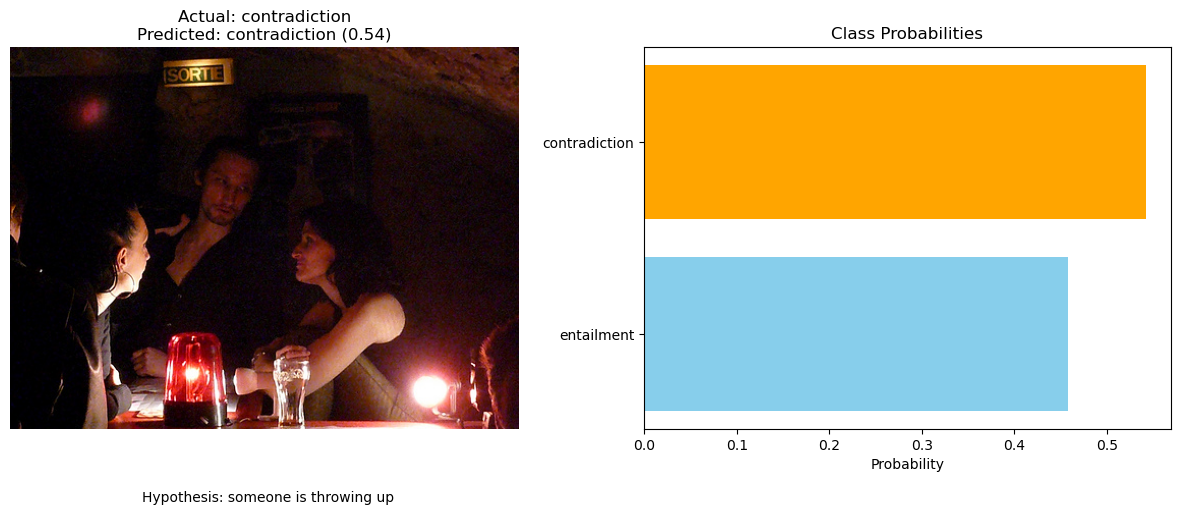

Sample index: 11800 | Image ID: 3266399073
Actual Label: contradiction | Predicted Label: contradiction (0.54)
All probabilities: {'contradiction': 0.5418354272842407, 'entailment': 0.45816463232040405}


In [15]:
def load_best_tuned_model(results_file=RESULTS_FILE, weights_path='best_tuned_model.weights.h5'):
    if not os.path.exists(results_file):
        print(f"Results file not found at {results_file}")
        return None, None
    with open(results_file, 'rb') as f:
        res = pickle.load(f)
    best_params = res.get('best_params', None)
    if best_params is None:
        print("best_params not found in results file.")
        return None, None

    model = create_tuned_model(**best_params)
    if model is None:
        print("Failed to create tuned model from best_params.")
        return None, None
    if not os.path.exists(weights_path):
        print(f"Weights file not found: {weights_path}")
        return None, None

    model.load_weights(weights_path)
    print("Loaded best tuned model weights.")
    return model, best_params

def predict_and_visualize_tuned_multiple(n_samples=5, model=None, class_names=None):
    if model is None:
        model, _ = load_best_tuned_model()
        if model is None:
            return

    if class_names is None:
        class_names = [index_to_label[i] for i in range(len(index_to_label))]
        
    sample_indices = np.random.choice(test_indices, size=n_samples, replace=False)

    for sample_df_index in sample_indices:
        row = df.loc[sample_df_index]
        image_id = row['Image_ID']
        hypothesis_text = row['Hypothesis']
        true_label = row['Label']

        img_path = os.path.join(IMAGES_FOLDER, f"{image_id}.jpg")
        img_bgr = cv2.imread(img_path)
        if img_bgr is None:
            print(f"Could not load image: {img_path}")
            continue
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        img_resized = cv2.resize(img_rgb, IMAGE_SIZE)
        img_norm = img_resized.astype(np.float32) / 255.0
        img_batch = np.expand_dims(img_norm, axis=0)

        text_seq = hypothesis_data[sample_df_index]
        text_batch = np.expand_dims(text_seq, axis=0)

        inputs = {"image_input": img_batch, "text_input": text_batch}
        preds = model.predict(inputs, verbose=0)[0]

        pred_idx = int(np.argmax(preds))
        pred_label = class_names[pred_idx]
        pred_conf = float(preds[pred_idx])

        plt.figure(figsize=(12, 5))

        plt.subplot(1, 2, 1)
        plt.imshow(img_rgb)
        plt.axis('off')
        title_text = f"Actual: {true_label}\nPredicted: {pred_label} ({pred_conf:.2f})"
        plt.title(title_text, fontsize=12)
        short_h = hypothesis_text if len(hypothesis_text) < 120 else hypothesis_text[:117] + "..."
        plt.figtext(0.13, 0.02, f"Hypothesis: {short_h}", wrap=True, ha='left', fontsize=10)

        plt.subplot(1, 2, 2)
        y_pos = np.arange(len(class_names))
        plt.barh(y_pos, preds, color='skyblue')
        plt.yticks(y_pos, class_names)
        plt.gca().invert_yaxis()
        plt.xlabel('Probability')
        plt.title('Class Probabilities')
        plt.barh(pred_idx, preds[pred_idx], color='orange')

        plt.tight_layout(rect=[0, 0.05, 1, 1])
        plt.show()

        prob_dict = {class_names[i]: float(preds[i]) for i in range(len(class_names))}
        print(f"Sample index: {sample_df_index} | Image ID: {image_id}")
        print(f"Actual Label: {true_label} | Predicted Label: {pred_label} ({pred_conf:.2f})")
        print("All probabilities:", prob_dict)
        print("="*80)

best_model, _ = load_best_tuned_model(results_file=RESULTS_FILE, weights_path='best_tuned_model.weights.h5')
predict_and_visualize_tuned_multiple(n_samples=5, model=best_model)

# Future Data Set Prediction

In [16]:
def _infer_embedding_rows_from_h5(weights_path):
    try:
        import h5py
        with h5py.File(weights_path, 'r') as f:
            found_shape = None
            def visitor(name, obj):
                nonlocal found_shape
                if found_shape is not None:
                    return
                if isinstance(obj, h5py.Dataset):
                    if name.endswith('text_embedding/embeddings') or name.endswith('embeddings:0') or ('text_embedding' in name and 'embeddings' in name):
                        found_shape = obj.shape
            f.visititems(visitor)
            if found_shape is not None:
                return int(found_shape[0])
    except Exception as e:
        print(f"Could not infer embedding rows from {weights_path}: {e}")
    return None

def load_best_tuned_model_for_inference(results_file=RESULTS_FILE, weights_path='best_tuned_model.weights.h5'):
    with open(results_file, 'rb') as f:
        res = pickle.load(f)
    best_params = res.get('best_params', None)
    if best_params is None:
        raise RuntimeError("best_params not found in results file.")

    global SAFE_VOCAB_SIZE
    original_vocab = SAFE_VOCAB_SIZE
    model = create_tuned_model(**best_params)
    try:
        model.load_weights(weights_path)
        return model, best_params
    except Exception as e:
        print(f"load attempt failed: {e}")
        inferred_rows = _infer_embedding_rows_from_h5(weights_path)
        if inferred_rows is None:
            raise
        print(f"Rebuilding model with inferred embedding rows: {inferred_rows}")
        SAFE_VOCAB_SIZE = int(inferred_rows)
        model = create_tuned_model(**best_params)
        model.load_weights(weights_path)
        SAFE_VOCAB_SIZE = original_vocab
        return model, best_params

def _preprocess_image(image_path, image_size):
    img = cv2.imread(image_path)
    if img is None:
        img_rgb = np.zeros((image_size[1], image_size[0], 3), dtype=np.uint8)
    else:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_rgb = cv2.resize(img_rgb, image_size)
    return (img_rgb.astype(np.float32) / 255.0)

def predict_future_to_csv(
    test_jsonl_path='A2_test_v3_final.jsonl',
    images_folder='A2_test_Images',
    out_csv='s4085077_predictions.csv',
    batch_size=128,
    results_file=RESULTS_FILE,
    weights_path='best_tuned_model.weights.h5'
):
    class_names = [index_to_label[i] for i in range(len(index_to_label))]

    model, _ = load_best_tuned_model_for_inference(results_file=results_file, weights_path=weights_path)

    records = []
    with open(test_jsonl_path, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            obj = json.loads(line)
            img_id = str(obj['Image_ID'])
            hyp = obj['Hypothesis']
            records.append((img_id, hyp))
    if not records:
        raise RuntimeError("No records found in test file.")

    texts = [hyp for (_, hyp) in records]
    seqs = tokenizer.texts_to_sequences(texts)
    text_matrix = pad_sequences(seqs, maxlen=MAX_SEQUENCE_LENGTH)

    preds_all = []
    for start in tqdm(range(0, len(records), batch_size), desc="Predicting"):
        end = min(start + batch_size, len(records))
        batch = records[start:end]

        batch_imgs = np.zeros((len(batch), IMAGE_SIZE[1], IMAGE_SIZE[0], 3), dtype=np.float32)
        for i, (img_id, _) in enumerate(batch):
            img_path = os.path.join(images_folder, f"{img_id}.jpg")
            batch_imgs[i] = _preprocess_image(img_path, IMAGE_SIZE)

        batch_text = text_matrix[start:end]
        batch_preds = model.predict({"image_input": batch_imgs, "text_input": batch_text}, verbose=0)
        preds_all.append(batch_preds)

    preds_all = np.vstack(preds_all)
    pred_indices = np.argmax(preds_all, axis=1)
    pred_labels = [class_names[i] for i in pred_indices]

    df_out = pd.DataFrame({
        "Image_ID": [f"{img_id}.jpg" for (img_id, _) in records],
        "Hypothesis": [hyp for (_, hyp) in records],
        "Label": pred_labels
    })
    df_out.to_csv(out_csv, index=False)
    print(f"Saved predictions to {out_csv}")
    return df_out

pred_df = predict_future_to_csv(
    test_jsonl_path='A2_test_v3_final.jsonl',
    images_folder='A2_test_Images',
    out_csv='s4085077_predictions.csv',
    batch_size=128,
    results_file=RESULTS_FILE,
    weights_path='best_tuned_model.weights.h5'
)

print(pred_df.head(10))

Predicting: 100%|██████████| 94/94 [02:44<00:00,  1.75s/it]

Saved predictions to s4085077_predictions.csv
             Image_ID                                         Hypothesis  \
0  20851016887272.jpg                       The person is on the swings.   
1  20851016887272.jpg                              A person is climbing.   
2  20851016887272.jpg                                 People sunbathing.   
3  20851016887272.jpg                Those people like flying squirrels.   
4  20851016887272.jpg                          There are people on rocks   
5  20851016887272.jpg              Everyone climbed the rock except one.   
6  20851016887272.jpg  Many people are miraculously climbing a tall m...   
7  20851016887272.jpg                    A group of people are swimming.   
8  20851016887272.jpg    A man is securing rope for his fellow climbers.   
9  20851016887272.jpg                    A group of people are outdoors.   

           Label  
0     entailment  
1     entailment  
2  contradiction  
3  contradiction  
4     entailment  
5  

# Reference -

Independent Test Data :
        
        Ishant Chintapatla, Kazuma Choji, and Naaisha Agarwal. (2025). COREVQA [Data set]. Kaggle.                           
        https://doi.org/10.34740/KAGGLE/DSV/12548912